# Drop-Off Prediction Modeling

This notebook was split from the original G'Contest final-round working notebook for faster GitHub review. Raw data and data-loading code are intentionally excluded. Saved outputs are preserved so interviewers can inspect the completed analysis and results without rerunning the private dataset.

**Interview focus:** Compares XGBoost, Random Forest, and LightGBM for predicting whether a customer drops off on the final attempt.


# **V. Modeling - Dự đoán khách hàng có drop off hay không trong lần thử cuối cùng**

In [172]:
# Lấy bản ghi cuối cùng mỗi customer_id (chuẩn hóa rồi)
df_user = df_model_combine.groupby('customer_id').tail(1).copy()
df_user['drop_off'] = (df_user['status'] != 'succeed').astype(int)

# Đầu vào cho user-based prediction:
X_user = df_user.drop(columns=['customer_id', 'status', 'stop_point_mapped','drop_off'])
y_user = df_user['drop_off']

print(X_user.shape, y_user.value_counts())

(9148, 21) drop_off
0    8543
1     605
Name: count, dtype: int64


## XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.8, 'xgb__n_estimators': 100, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
📈 CV score mean: 0.9078


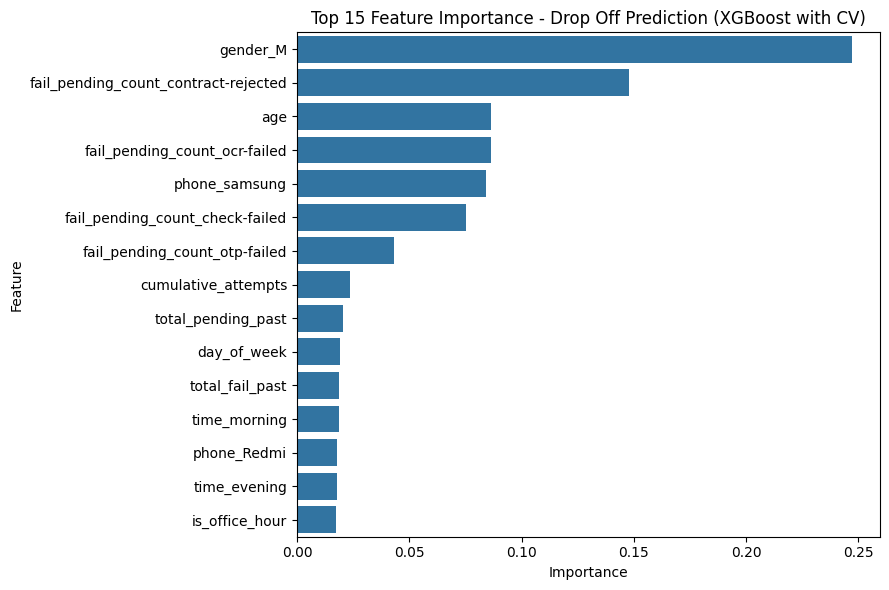

✅ Top 15 features:
                                 Feature  Importance
14                              gender_M    0.247273
12  fail_pending_count_contract-rejected    0.147924
0                                    age    0.086514
10         fail_pending_count_ocr-failed    0.086465
18                         phone_samsung    0.084298
13       fail_pending_count_check-failed    0.075122
8          fail_pending_count_otp-failed    0.043174
3                    cumulative_attempts    0.023460
5                     total_pending_past    0.020631
2                            day_of_week    0.019150
4                        total_fail_past    0.018574
20                          time_morning    0.018494
17                           phone_Redmi    0.017854
19                          time_evening    0.017743
6                         is_office_hour    0.017535

📊 Đánh giá mô hình - Drop Off Prediction:
      Metric  Mean Score
0    ROC AUC    0.907838
1   Accuracy    0.932991
2   F1 Score   

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user  # Đầu vào đã tạo trước đó
y = df_user['drop_off']  # Target đã tạo (1: drop-off, 0: thành công)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (XGBoost with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction:")
print(cv_summary)


In [ ]:
# Dependency note: SHAP is required for model explainability in this section.
!pip install shap
import shap
import matplotlib.pyplot as plt

# final_model: mô hình XGBoost đã được fit
# X_user: tập dữ liệu đầu vào (không chứa drop_off)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_user)


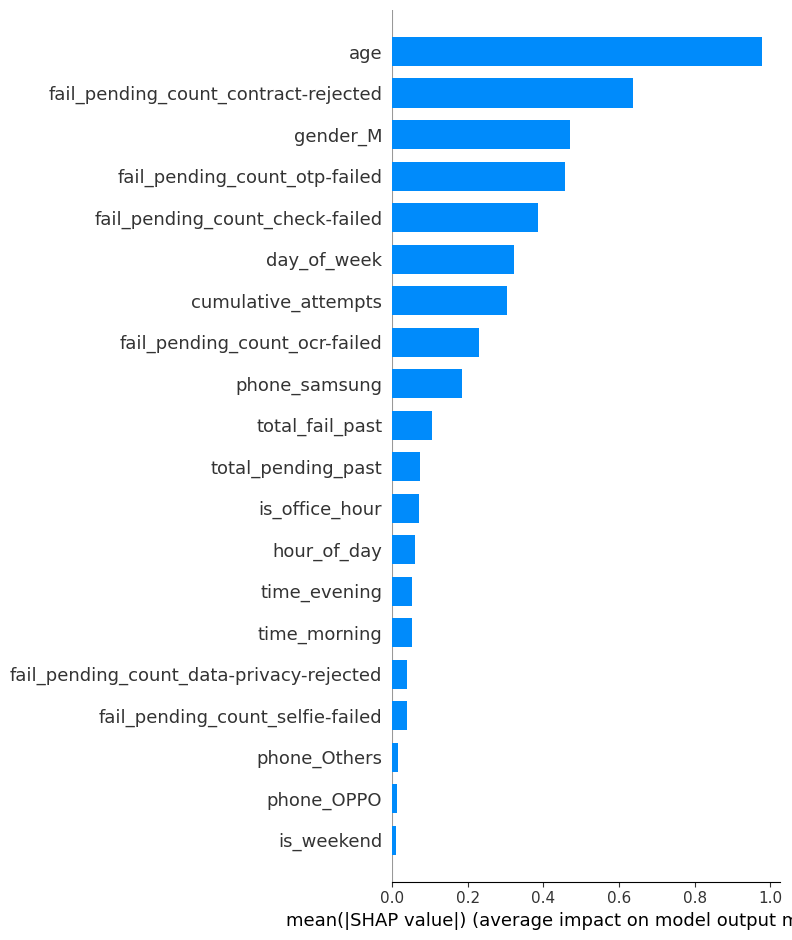

In [ ]:
shap.summary_plot(shap_values, X_user, plot_type='bar')


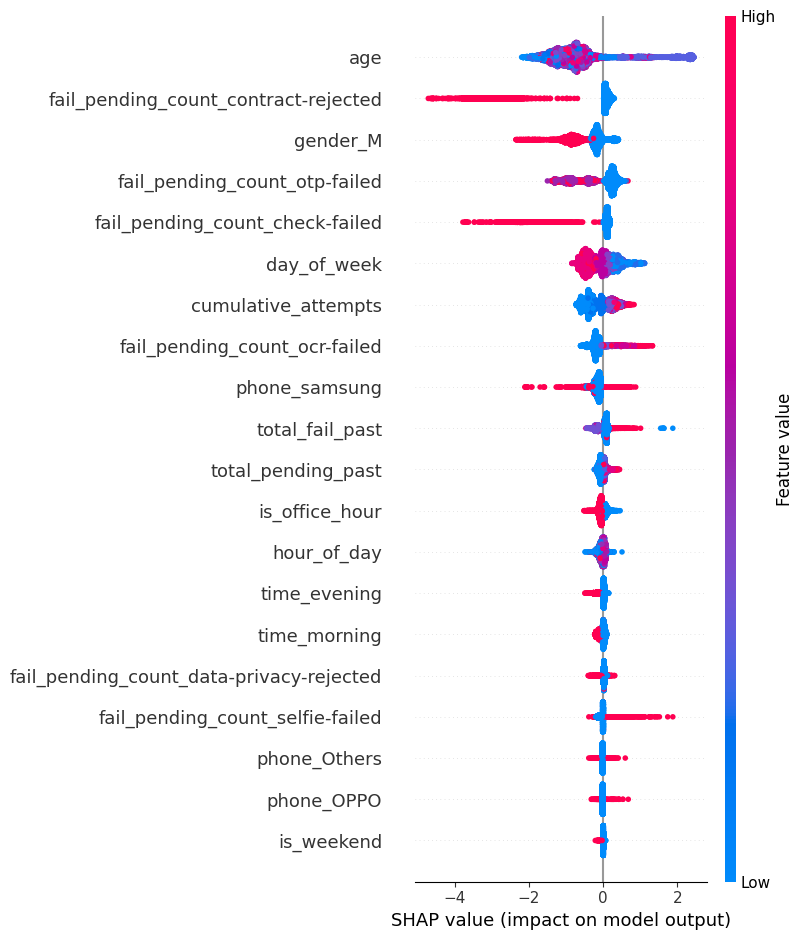

In [ ]:
shap.summary_plot(shap_values, X_user)


## Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': None}
📈 CV score mean: 0.9056


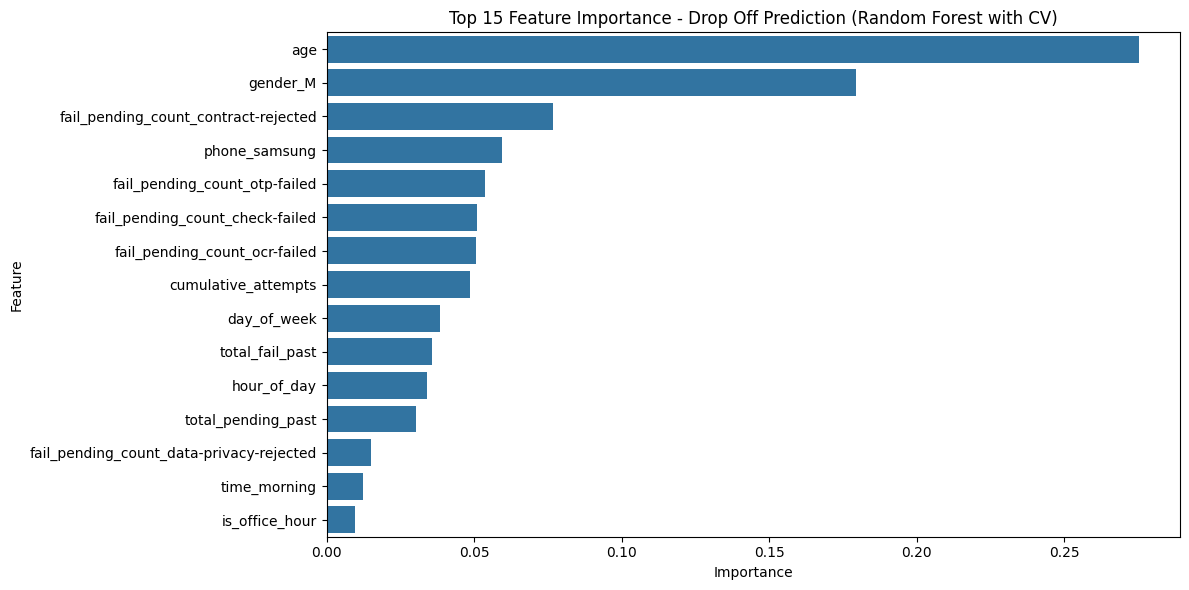

✅ Top 15 features:
                                     Feature  Importance
0                                        age    0.275542
14                                  gender_M    0.179614
12      fail_pending_count_contract-rejected    0.076839
18                             phone_samsung    0.059613
8              fail_pending_count_otp-failed    0.053841
13           fail_pending_count_check-failed    0.050929
10             fail_pending_count_ocr-failed    0.050732
3                        cumulative_attempts    0.048647
2                                day_of_week    0.038279
4                            total_fail_past    0.035653
1                                hour_of_day    0.034130
5                         total_pending_past    0.030352
9   fail_pending_count_data-privacy-rejected    0.015124
20                              time_morning    0.012424
6                             is_office_hour    0.009562

📊 Đánh giá mô hình - Drop Off Prediction (Random Forest):
      Metr

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user
y = df_user['drop_off']

# 2. SMOTE + Random Forest Pipeline
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 7, 10, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_rf = best_model.named_steps['rf']
final_rf.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (Random Forest with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction (Random Forest):")
print(cv_summary)


## LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 8543, number of negative: 8543
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1904
[LightGBM] [Info] Number of data points in the train set: 17086, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Best hyperparameters:
{'lgb__subsample': 0.6, 'lgb__num_leaves': 15, 'lgb__n_estimators': 300, 'lgb__max_depth': -1, 'lgb__learning_rate': 0.05, 'lgb__colsample_bytree': 1.0}
📈 CV score mean: 0.9056
[LightGBM] [Info] Number of positive: 8543, number of negative: 8543
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And i

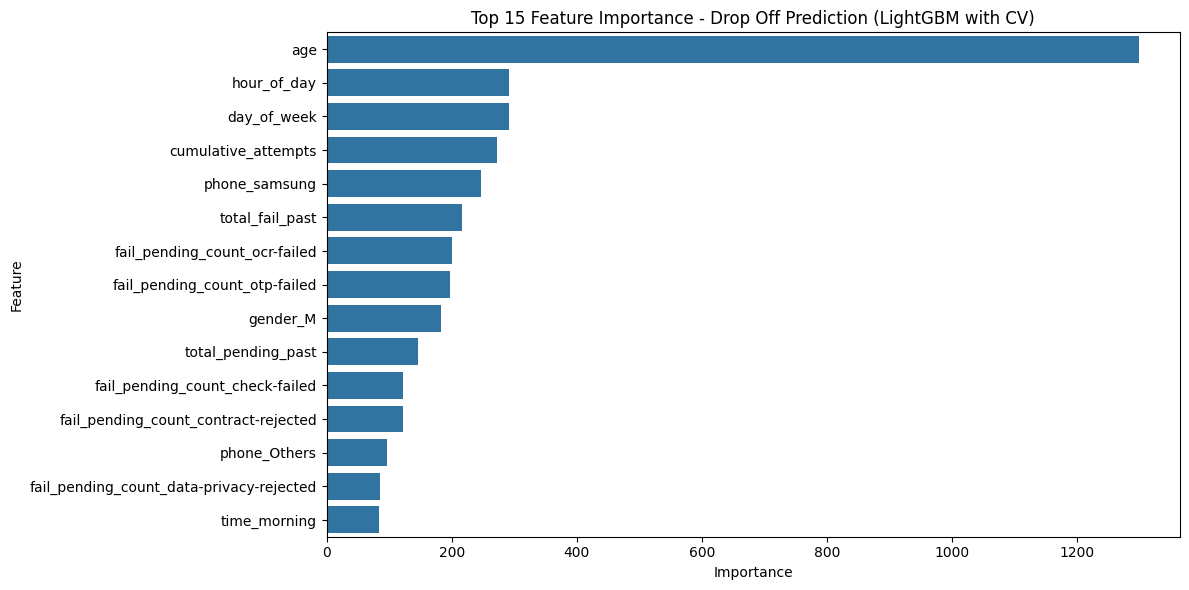

✅ Top 15 features:
                                     Feature  Importance
0                                        age        1299
1                                hour_of_day         291
2                                day_of_week         291
3                        cumulative_attempts         272
18                             phone_samsung         247
4                            total_fail_past         216
10             fail_pending_count_ocr-failed         201
8              fail_pending_count_otp-failed         197
14                                  gender_M         183
5                         total_pending_past         146
13           fail_pending_count_check-failed         122
12      fail_pending_count_contract-rejected         122
16                              phone_Others          96
9   fail_pending_count_data-privacy-rejected          85
20                              time_morning          83
[LightGBM] [Info] Number of positive: 6834, number of negative: 6834


In [ ]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user
y = df_user['drop_off']

# 2. SMOTE + LightGBM Pipeline
lgb = LGBMClassifier(
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [5, 7, 10, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 63],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_lgb = best_model.named_steps['lgb']
final_lgb.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (LightGBM with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction (LightGBM):")
print(cv_summary)


In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Split': final_lgb.booster_.feature_importance(importance_type='split'),
    'Gain': final_lgb.booster_.feature_importance(importance_type='gain')
})

# Chuẩn nhất: Sắp xếp theo 'Gain'
importance_df = importance_df.sort_values(by='Gain', ascending=False)
print(importance_df.head(15))


                                 Feature  Split          Gain
0                                    age   1299  70891.969741
14                              gender_M    183  40988.374092
12  fail_pending_count_contract-rejected    122  17766.445103
18                         phone_samsung    247  14728.709603
10         fail_pending_count_ocr-failed    201  13086.798923
3                    cumulative_attempts    272   9209.752347
13       fail_pending_count_check-failed    122   6823.720046
8          fail_pending_count_otp-failed    197   6447.351134
2                            day_of_week    291   6260.673069
4                        total_fail_past    216   4046.569392
5                     total_pending_past    146   2323.119700
1                            hour_of_day    291   2274.080078
20                          time_morning     83   2208.435865
19                          time_evening     62   1427.727685
16                          phone_Others     96   1372.277646


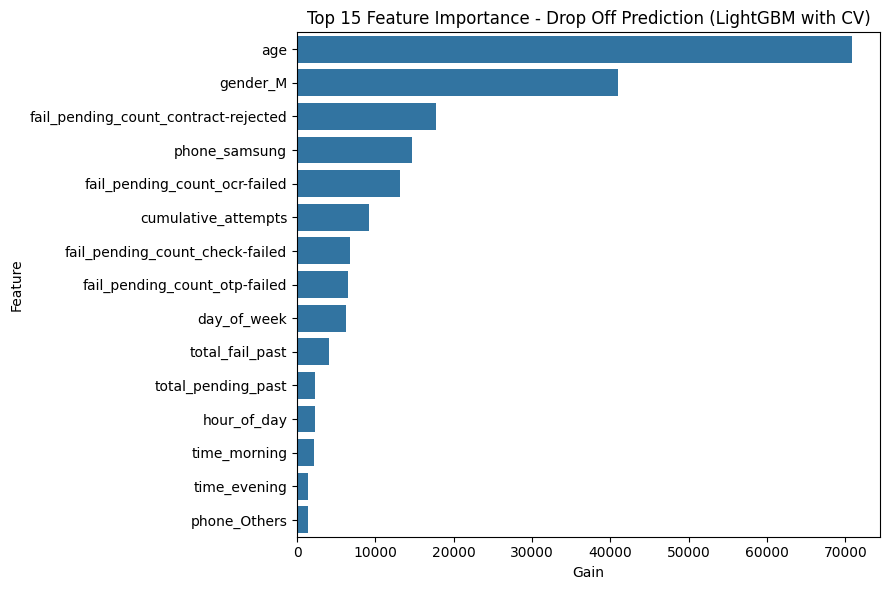

In [ ]:
plt.figure(figsize=(9, 6))
sns.barplot(x='Gain', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (LightGBM with CV)")
plt.tight_layout()
plt.show()